In [ ]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
from dataclasses import dataclass, field
from typing import Literal, Union, Dict, Optional
from pathlib import Path


ee.Authenticate()
ee.Initialize(project="YOUR_PROJECT_HERE")


# ══════════════════════════════════════════════════════════════════════════════
# Configuration
# ══════════════════════════════════════════════════════════════════════════════

@dataclass
class AnalysisConfig:
    """
    Central configuration for an NDVI analysis run.
    Separating config from logic makes the functions reusable across
    regions and time periods without touching function signatures.

    Args:
        study_start:        Start of study period (ISO string).
        study_end:          End of study period (ISO string).
        baseline_start:     Start of baseline period (ISO string).
        baseline_end:       End of baseline period (ISO string).
        intervention_date:  Date of intervention (ISO string). Used for
                            annotations on charts, not for filtering.
        cloud_threshold:    Max CLOUDY_PIXEL_PERCENTAGE for S2 filtering.
        scale:              Spatial scale in metres for reduceRegion.
        reducer:            "median" (default) or "mean" for compositing.
        seasons:            Dict of season definitions. Each entry:
                            {"months": [int, ...], "label": str}
        ndvi_viz:           GEE visualisation params for NDVI layers.
        anomaly_viz:        GEE visualisation params for anomaly layers.
        zscore_viz:         GEE visualisation params for z-score layers.
        export_crs:         CRS for GeoTIFF export (default EPSG:4326).
        export_scale:       Scale in metres for GeoTIFF export.
    """

    study_start:       str = "2022-01-01"
    study_end:         str = "2026-04-30"
    baseline_start:    str = "2018-01-01"
    baseline_end:      str = "2023-12-31"
    intervention_date: str = "2024-10-01"
    cloud_threshold:   int = 20
    scale:             int = 20
    reducer:           Literal["median", "mean"] = "median"

    seasons: dict = field(default_factory=lambda: {
        "dry1": {"months": [1, 2],       "label": "Dry Season 1 (JF)"},
        "gu":   {"months": [3, 4, 5],    "label": "Gu (Long Rains, MAM)"},
        "dry2": {"months": [6, 7, 8, 9], "label": "Dry Season 2 (JJAS)"},
        "deyr": {"months": [10, 11, 12], "label": "Deyr (Short Rains, OND)"},
    })

    ndvi_viz: dict = field(default_factory=lambda: {
        "min": 0.0, "max": 0.8,
        "palette": ["#d73027", "#fc8d59", "#fee08b", "#d9ef8b", "#91cf60", "#1a9850"],
    })
    anomaly_viz: dict = field(default_factory=lambda: {
        "min": -0.3, "max": 0.3,
        "palette": ["#d73027", "#fc8d59", "#ffffbf", "#91cf60", "#1a9850"],
    })
    zscore_viz: dict = field(default_factory=lambda: {
        "min": -3, "max": 3,
        "palette": ["#d73027", "#ffffbf", "#1a9850"],
    })

    export_crs:   str = "EPSG:4326"
    export_scale: int = 10   # 10m for export — finer than analysis scale


# ══════════════════════════════════════════════════════════════════════════════
# Geometry helpers
# ══════════════════════════════════════════════════════════════════════════════

# Type alias — used throughout
GEEGeometry = Union[ee.Geometry, ee.Feature, ee.FeatureCollection]


def fc_from_geojson(path: Union[str, Path]) -> ee.FeatureCollection:
    """Load a local GeoJSON file as an ee.FeatureCollection."""
    with open(path, "r") as f:
        geojson = json.load(f)
    return ee.FeatureCollection(geojson)


def to_geometry(region: GEEGeometry) -> ee.Geometry:
    """
    Normalise any GEE region type to ee.Geometry.
    Needed because filterBounds, reduceRegion, etc. behave differently
    depending on whether they receive a Geometry, Feature, or FeatureCollection.
    """
    if isinstance(region, ee.FeatureCollection):
        return region.geometry()
    if isinstance(region, ee.Feature):
        return region.geometry()
    return region


# ══════════════════════════════════════════════════════════════════════════════
# Core collection builder
# ══════════════════════════════════════════════════════════════════════════════

def build_s2_ndvi_collection(
    geometry: GEEGeometry,
    start_date: str,
    end_date: str,
    cloud_threshold: int = 20,
) -> ee.ImageCollection:
    """
    Return a cloud-masked, NDVI-only Sentinel-2 SR collection.
    This is the single entry point for raw data — all other functions
    filter down from here rather than rebuilding.
    """

    def mask_clouds(image: ee.Image) -> ee.Image:
        qa          = image.select("QA60")
        scl         = image.select("SCL")
        cloud_mask  = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
        shadow_mask = scl.neq(3)
        return (
            image
            .updateMask(cloud_mask.And(shadow_mask))
            .divide(10000)
            .copyProperties(image, ["system:time_start"])
        )

    def add_ndvi(image: ee.Image) -> ee.Image:
        return image.addBands(
            image.normalizedDifference(["B8", "B4"]).rename("NDVI")
        )

    return (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(to_geometry(geometry))
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cloud_threshold))
        .map(mask_clouds)
        .map(add_ndvi)
        .select("NDVI")
    )


# ══════════════════════════════════════════════════════════════════════════════
# Internal helpers
# ══════════════════════════════════════════════════════════════════════════════

def _get_reducer(reducer: Literal["median", "mean"]) -> ee.Reducer:
    return ee.Reducer.median() if reducer == "median" else ee.Reducer.mean()



def _collection_to_dataframe(
    collection: ee.ImageCollection,
    geometry: GEEGeometry,
    scale: int,
    properties: list[str],
    zone_label: str,
    band_names: list[str] = ["NDVI"],
) -> pd.DataFrame:
    """
    Reduce an ImageCollection to a scalar-per-image DataFrame.

    Args:
        band_names: List of bands to extract from reduceRegion
                    (e.g. ["NDVI"] or ["NDVI_mean", "NDVI_stdDev"])
    """
    geom = to_geometry(geometry)

    def extract(image: ee.Image) -> ee.Feature:
        stats = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geom,
            scale=scale,
            maxPixels=1e9,
        )

        props = {p: image.get(p) for p in properties}
        for band in band_names:
            props[band] = stats.get(band)

        props["zone"] = zone_label
        return ee.Feature(None, props)

    rows = ee.FeatureCollection(collection.map(extract)).getInfo()["features"]
    return pd.DataFrame([f["properties"] for f in rows])


def _safe_composite(
    collection: ee.ImageCollection,
    reducer: ee.Reducer,
) -> ee.Image:
    """
    Reduce a collection to a composite, returning a fully masked image
    if the collection is empty. Prevents band-not-found errors downstream.
    """
    empty = ee.Image.constant(0).selfMask().rename("NDVI")
    return ee.Image(
        ee.Algorithms.If(
            collection.size().gt(0),
            collection.reduce(reducer).rename("NDVI"),
            empty,
        )
    )


# ══════════════════════════════════════════════════════════════════════════════
# Monthly composites
# ══════════════════════════════════════════════════════════════════════════════

def monthly_ndvi(
    geometry: GEEGeometry,
    config: AnalysisConfig = None,
    zone_label: str = "zone",
) -> dict:
    """
    Compute monthly NDVI composites over the study period.

    Builds the full S2 collection once, then filters per month — avoids
    redundant collection instantiation for every time step.

    Returns:
        {
          "collection": ee.ImageCollection,  # one image per month, 'NDVI' band
          "dataframe":  pd.DataFrame,        # columns: date, ndvi, n_images, zone
        }
    """
    cfg = config or AnalysisConfig()
    _reducer = _get_reducer(cfg.reducer)

    # Build once, filter per month
    full_col = build_s2_ndvi_collection(
        geometry, cfg.study_start, cfg.study_end, cfg.cloud_threshold
    )

    start    = ee.Date(cfg.study_start)
    end      = ee.Date(cfg.study_end)
    n_months = end.difference(start, "month").round()
    offsets  = ee.List.sequence(0, n_months.subtract(1))

    def composite_one_month(offset: ee.Number) -> ee.Image:
        month_start = start.advance(offset, "month")
        month_end   = month_start.advance(1, "month")
        monthly     = full_col.filterDate(month_start, month_end)

        return (
            _safe_composite(monthly, _reducer)
            .set("year",              month_start.get("year"))
            .set("month",             month_start.get("month"))
            .set("system:time_start", month_start.millis())
            .set("date_label",        month_start.format("YYYY-MM"))
            .set("n_images",          monthly.size())
        )

    monthly_col = ee.ImageCollection(offsets.map(composite_one_month))

    df = _collection_to_dataframe(
        monthly_col, geometry, cfg.scale,
        properties=["date_label", "n_images"],
        zone_label=zone_label,
        band_names=["NDVI"]
    )
    df = df.rename(columns={"date_label": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    return {"collection": monthly_col, "dataframe": df}


# ══════════════════════════════════════════════════════════════════════════════
# Seasonal composites
# ══════════════════════════════════════════════════════════════════════════════

def seasonal_ndvi(
    geometry: GEEGeometry,
    config: AnalysisConfig = None,
    zone_label: str = "zone",
) -> dict:
    """
    Compute per-season NDVI composites for each year in the study period.

    Builds the full S2 collection once, then filters per season/year.

    Returns:
        {
          "collection": ee.ImageCollection,  # one image per (year, season)
          "dataframe":  pd.DataFrame,        # columns: year, season, season_label,
                                             #          ndvi, n_images, zone
        }
    """
    cfg      = config or AnalysisConfig()
    _reducer = _get_reducer(cfg.reducer)

    start_year = int(cfg.study_start[:4])
    end_year   = int(cfg.study_end[:4])

    # Build full collection once
    full_col = build_s2_ndvi_collection(
        geometry, cfg.study_start, cfg.study_end, cfg.cloud_threshold
    )

    images = []
    for year in range(start_year, end_year + 1):
        for season_key, season_info in cfg.seasons.items():
            months  = season_info["months"]
            s_start = ee.Date.fromYMD(year, months[0], 1)

            # Filter the already-built collection — no redundant S2 query
            seasonal = full_col.filter(
                ee.Filter.calendarRange(months[0], months[-1], "month")
            ).filterDate(
                f"{year}-{months[0]:02d}-01",
                f"{year}-{months[-1]:02d}-28",
            )

            image = (
                _safe_composite(seasonal, _reducer)
                .set("year",              year)
                .set("season",            season_key)
                .set("season_label",      season_info["label"])
                .set("system:time_start", s_start.millis())
                .set("n_images",          seasonal.size())
            )
            images.append(image)

    seasonal_col = ee.ImageCollection(images)

    df = _collection_to_dataframe(
        seasonal_col, geometry, cfg.scale,
        properties=["year", "season", "season_label", "n_images"],
        zone_label=zone_label,
        band_names=["NDVI"]
    )
    df = df.sort_values(["year", "season"]).reset_index(drop=True)

    return {"collection": seasonal_col, "dataframe": df}


# ══════════════════════════════════════════════════════════════════════════════
# Baseline
# ══════════════════════════════════════════════════════════════════════════════

def compute_monthly_baseline(
    geometry: GEEGeometry,
    config: AnalysisConfig = None,
    zone_label: str = "zone",
) -> dict:
    """
    Compute per-calendar-month NDVI statistics over the baseline period.
    Builds the S2 collection once and filters per calendar month.

    Returns:
        {
          "dataframe":   pd.DataFrame,        # stats per calendar month
          "mean_images": ee.ImageCollection,  # one mean image per month
          "std_images":  ee.ImageCollection,  # one std image per month
        }
    """
    cfg = config or AnalysisConfig()

    collection = build_s2_ndvi_collection(
        geometry, cfg.baseline_start, cfg.baseline_end, cfg.cloud_threshold
    )
    months = ee.List.sequence(1, 12)

    def stats_for_month(month: ee.Number) -> ee.Image:
        month   = ee.Number(month)
        monthly = collection.filter(ee.Filter.calendarRange(month, month, "month"))
        empty   = ee.Image.constant(0).selfMask().rename("NDVI")

        stats_image = ee.Algorithms.If(
            monthly.size().gt(0),
            monthly.reduce(
                ee.Reducer.mean()
                .combine(ee.Reducer.median(), sharedInputs=True)
                .combine(ee.Reducer.stdDev(), sharedInputs=True)
                .combine(ee.Reducer.min(),    sharedInputs=True)
                .combine(ee.Reducer.max(),    sharedInputs=True)
                .combine(ee.Reducer.count(),  sharedInputs=True)
            ),
            empty,
        )

        return (
            ee.Image(stats_image)
            .set("month",    month)
            .set("n_images", monthly.size())
        )

    baseline_col = ee.ImageCollection(months.map(stats_for_month))

    mean_images = baseline_col.map(
        lambda img: img.select("NDVI_mean")
                      .rename("NDVI")
                      .set("month", img.get("month"))
    )
    std_images = baseline_col.map(
        lambda img: img.select("NDVI_stdDev")
                      .rename("NDVI_std")
                      .set("month", img.get("month"))
    )

    df = _collection_to_dataframe(
        baseline_col, geometry, cfg.scale,
        properties=["month", "n_images"],
        zone_label=zone_label,
        band_names=[
                "NDVI_mean",
                "NDVI_median",
                "NDVI_stdDev",
                "NDVI_min",
                "NDVI_max",
                "NDVI_count",
            ],
    )
    # Rename stat bands to match expected column names
    df = df.rename(columns={
        "NDVI_mean":   "mean",
        "NDVI_median": "median",
        "NDVI_stdDev": "std",
        "NDVI_min":    "min",
        "NDVI_max":    "max",
        "NDVI_count":  "count",
    })
    df["month"] = df["month"].astype(int)

    return {
        "dataframe":   df.sort_values("month").reset_index(drop=True),
        "mean_images": mean_images,
        "std_images":  std_images,
    }


# ══════════════════════════════════════════════════════════════════════════════
# Anomaly images
# ══════════════════════════════════════════════════════════════════════════════

def compute_anomaly_images(
    study_collection: ee.ImageCollection,
    baseline_mean_images: ee.ImageCollection,
    baseline_std_images: ee.ImageCollection,
    temporal_resolution: Literal["monthly", "seasonal"] = "monthly",
    config: AnalysisConfig = None,
) -> ee.ImageCollection:
    """
    Add anomaly_abs and z_score bands to every image in the study collection.

    Monthly:  matches baseline on 'month' property.
    Seasonal: averages baseline images across the months in each season.

    Returns ee.ImageCollection with bands: NDVI, anomaly_abs, z_score.
    """
    cfg = config or AnalysisConfig()

    # Build a server-side season→months dictionary from config
    # so seasons are not hardcoded here
    season_months_dict = ee.Dictionary({
        k: v["months"] for k, v in cfg.seasons.items()
    })

    def add_anomaly(image: ee.Image) -> ee.Image:
        if temporal_resolution == "monthly":
            month = image.get("month")
            b_mean = ee.Image(
                baseline_mean_images.filter(ee.Filter.eq("month", month)).first()
            )
            b_std = ee.Image(
                baseline_std_images.filter(ee.Filter.eq("month", month)).first()
            )
        else:
            month_list = ee.List(season_months_dict.get(image.get("season")))
            b_mean = baseline_mean_images.filter(
                ee.Filter.inList("month", month_list)
            ).mean()
            b_std = baseline_std_images.filter(
                ee.Filter.inList("month", month_list)
            ).mean()

        anomaly_abs = image.select("NDVI").subtract(b_mean).rename("anomaly_abs")
        z_score     = anomaly_abs.divide(b_std).rename("z_score")

        return (
            image
            .addBands(anomaly_abs)
            .addBands(z_score)
            .copyProperties(image, [
                "year", "month", "season", "season_label",
                "system:time_start", "date_label", "n_images",
            ])
        )

    return study_collection.map(add_anomaly)


# ══════════════════════════════════════════════════════════════════════════════
# Anomaly DataFrame
# ══════════════════════════════════════════════════════════════════════════════

def compute_anomalies(
    study_df: pd.DataFrame,
    baseline_df: pd.DataFrame,
    config: AnalysisConfig = None,
    temporal_resolution: Literal["monthly", "seasonal"] = "monthly",
) -> pd.DataFrame:
    """
    Join study-period NDVI with baseline stats and compute anomaly columns.
    Works for both monthly (joins on 'month') and seasonal (aggregates
    baseline months per season then joins on 'season') resolutions.

    Adds columns: anomaly_abs, anomaly_pct, z_score.
    """
    cfg = config or AnalysisConfig()
    df  = study_df.copy()

    if temporal_resolution == "monthly":
        df["month"] = df["date"].dt.month
        join_key    = "month"
        bl          = baseline_df

    else:
        season_to_months = {k: v["months"] for k, v in cfg.seasons.items()}
        rows = []
        for season_key, months in season_to_months.items():
            subset = baseline_df[baseline_df["month"].isin(months)]
            for zone, grp in subset.groupby("zone"):
                rows.append({
                    "season": season_key,
                    "zone":   zone,
                    "mean":   grp["mean"].mean(),
                    "median": grp["median"].mean(),
                    "std":    grp["std"].mean(),
                    "min":    grp["min"].min(),
                    "max":    grp["max"].max(),
                })
        bl       = pd.DataFrame(rows)
        join_key = "season"

    df = df.merge(
        bl[[join_key, "mean", "median", "std", "min", "max", "zone"]],
        on=[join_key, "zone"],
        how="left",
    )
    df["anomaly_abs"] = df["NDVI"] - df["mean"]
    df["anomaly_pct"] = (df["anomaly_abs"] / df["mean"]) * 100
    df["z_score"]     = df["anomaly_abs"] / df["std"]

    if temporal_resolution == "monthly" and "month" not in study_df.columns:
        df = df.drop(columns="month")

    return df

# ══════════════════════════════════════════════════════════════════════════════
# Plot
# ══════════════════════════════════════════════════════════════════════════════
def barplot_ndvi_zscore(
    df: pd.DataFrame,
    intervention_date: Optional[str] = None,
    title: str = "NDVI Anomalies (Z-score)",
    figsize: tuple = (12, 6),
    month_interval: int = 2
):

    df = df.sort_values("date")
    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(
        df["date"],
        df["z_score"],
        color=df["z_score"].apply(
            lambda x: "#4daf4a" if x > 0 else "#e41a1c"
        ),
        width=20,  # days, good for monthly data
        alpha=0.85
    )

    ax.axhline(0, color="black", linewidth=0.8)

    ax.set_ylabel("NDVI anomaly (z-score)")
    ax.set_title("NDVI anomalies")


    # Shade intervention period
    if intervention_date is not None:
        intervention_date = pd.to_datetime(intervention_date)
        ax.axvspan(
            intervention_date,
            df["date"].max(),
            color="#fdb462",
            alpha=0.25,
            label="Post‑intervention"
        )

    # Control x-axis tick
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=month_interval)
    )
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y-%m")
    )
    
    # Subtle grid
    ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.5)


    # Thresholds
    ax.axhline(2, color="#890000", linestyle="--", linewidth=1)
    ax.axhline(-2, color="#890000", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.8)

    ax.set_ylabel("NDVI anomaly (z-score)")
    ax.set_title(title, fontsize=14, weight="bold")

    
    # Remove top/right spines for a cleaner look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Improve date label readability
    ax.tick_params(axis="x", rotation=90)

    # Optional legend (only if intervention is shown)
    if intervention_date is not None:
        ax.legend(frameon=False, loc="upper left")


    fig.tight_layout()
    return fig


# ══════════════════════════════════════════════════════════════════════════════
# Map display + GeoTIFF export
# ══════════════════════════════════════════════════════════════════════════════

def _get_image_from_collection(
    collection: ee.ImageCollection,
    date_label: str,
    temporal_resolution: Literal["monthly", "seasonal"],
) -> ee.Image:
    """
    Filter a collection to a single image by date_label.

    date_label format:
        monthly:  "YYYY-MM"      e.g. "2025-01"
        seasonal: "YYYY-season"  e.g. "2025-dry1"
    """
    year_str, period_str = date_label.split("-", maxsplit=1)
    year = int(year_str)

    if temporal_resolution == "monthly":
        return ee.Image(
            collection
            .filter(ee.Filter.eq("year",  year))
            .filter(ee.Filter.eq("month", int(period_str)))
            .first()
        )
    else:
        return ee.Image(
            collection
            .filter(ee.Filter.eq("year",   year))
            .filter(ee.Filter.eq("season", period_str))
            .first()
        )


def add_ndvi_layers_to_map(
    m: geemap.Map,
    collection: ee.ImageCollection,
    date_label: str,
    geometry: GEEGeometry,
    config: AnalysisConfig = None,
    label_prefix: str = "",
    temporal_resolution: Literal["monthly", "seasonal"] = "monthly",
    bands: list[str] = None,
    zoom: int = 13,
) -> None:
    """
    Add NDVI, anomaly and z-score layers to a geemap Map for a given period.

    Args:
        m:                    geemap.Map instance.
        collection:           Output of compute_anomaly_images().
        date_label:           "YYYY-MM" or "YYYY-seasonkey".
        geometry:             AOI to centre the map on.
        config:               AnalysisConfig (uses defaults if None).
        label_prefix:         Prepended to layer names.
        temporal_resolution:  "monthly" or "seasonal".
        bands:                Subset of ["NDVI", "anomaly_abs", "z_score"] to add.
                              Defaults to all three.
        zoom:                 Map zoom level.
    """
    cfg    = config or AnalysisConfig()
    bands  = bands or ["NDVI", "anomaly_abs", "z_score"]
    prefix = f"{label_prefix} " if label_prefix else ""
    image  = _get_image_from_collection(collection, date_label, temporal_resolution)

    band_configs = {
        "NDVI":        (cfg.ndvi_viz,    f"{prefix}NDVI {date_label}"),
        "anomaly_abs": (cfg.anomaly_viz, f"{prefix}Anomaly {date_label}"),
        "z_score":     (cfg.zscore_viz,  f"{prefix}Z-score {date_label}"),
    }

    for band in bands:
        if band in band_configs:
            viz, name = band_configs[band]
            m.addLayer(image.select(band), viz, name)

    m.centerObject(to_geometry(geometry), zoom=zoom)


def export_ndvi_to_tiff(
    collection: ee.ImageCollection,
    date_label: str,
    geometry: GEEGeometry,
    output_dir: Union[str, Path],
    config: AnalysisConfig = None,
    label_prefix: str = "",
    temporal_resolution: Literal["monthly", "seasonal"] = "monthly",
    bands: list[str] = None,
    to_drive: bool = False,
    drive_folder: str = "GEE_exports",
) -> None:
    """
    Export NDVI/anomaly bands as GeoTIFFs — either locally via geemap
    or to Google Drive via the GEE Tasks API.

    Local export uses geemap.ee_export_image() which downloads directly
    to disk. Drive export submits a GEE task (non-blocking).

    Args:
        collection:           Output of compute_anomaly_images().
        date_label:           "YYYY-MM" or "YYYY-seasonkey".
        geometry:             Export region.
        output_dir:           Local directory for GeoTIFF files.
        config:               AnalysisConfig (uses defaults if None).
        label_prefix:         Prepended to file names.
        temporal_resolution:  "monthly" or "seasonal".
        bands:                Bands to export. Defaults to all three.
        to_drive:             If True, export to Google Drive instead of locally.
        drive_folder:         Google Drive folder name (used when to_drive=True).
    """
    cfg        = config or AnalysisConfig()
    bands      = bands or ["NDVI", "anomaly_abs", "z_score"]
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    image  = _get_image_from_collection(collection, date_label, temporal_resolution)
    region = to_geometry(geometry)
    prefix = f"{label_prefix}_" if label_prefix else ""

    for band in bands:
        filename = f"{prefix}{band}_{date_label}"
        img_band = image.select(band)

        if to_drive:
            task = ee.batch.Export.image.toDrive(
                image=img_band,
                description=filename[:100],   # GEE task name limit
                folder=drive_folder,
                fileNamePrefix=filename,
                region=region,
                scale=cfg.export_scale,
                crs=cfg.export_crs,
                maxPixels=1e13,
                fileFormat="GeoTIFF",
            )
            task.start()
            print(f"[Drive] Task submitted: {filename}.tif")

        else:
            out_path = output_dir / f"{filename}.tif"
            geemap.ee_export_image(
                img_band,
                filename=str(out_path),
                scale=cfg.export_scale,
                region=region,
                crs=cfg.export_crs,
                file_per_band=False,
            )
            print(f"[Local] Saved: {out_path}")

# ══════════════════════════════════════════════════════════════════════════════
# CHIRPS precipitation
# ══════════════════════════════════════════════════════════════════════════════

def build_chirps_monthly(
    geometry: GEEGeometry,
    start_date: str,
    end_date: str,
    scale: int = 5500,
) -> dict:
    """
    Aggregate CHIRPS pentad data to monthly precipitation totals.

    Sums pentad images within each calendar month — correct for
    accumulation data (never use mean for rainfall totals).

    Returns:
        {
          "collection": ee.ImageCollection,  # monthly, band: 'precipitation'
          "dataframe":  pd.DataFrame,        # columns: date, precipitation,
                                             #          n_images, zone
        }

    Note:
        scale=5500 matches CHIRPS native ~5.5km resolution.
        Passing a finer scale just triggers unnecessary resampling.
    """
    geom = to_geometry(geometry)

    chirps = (
        ee.ImageCollection("UCSB-CHG/CHIRPS/PENTAD")
        .filterBounds(geom)
        .filterDate(start_date, end_date)
        .select("precipitation")
    )

    start    = ee.Date(start_date)
    end      = ee.Date(end_date)
    n_months = end.difference(start, "month").round()
    offsets  = ee.List.sequence(0, n_months.subtract(1))

    def sum_one_month(offset: ee.Number) -> ee.Image:
        month_start = start.advance(offset, "month")
        month_end   = month_start.advance(1, "month")
        monthly     = chirps.filterDate(month_start, month_end)

        # Empty guard — return masked image if no pentads found
        empty = ee.Image.constant(0).selfMask().rename("precipitation")
        composite = ee.Algorithms.If(
            monthly.size().gt(0),
            monthly.sum().rename("precipitation"),
            empty,
        )

        return (
            ee.Image(composite)
            .set("year",              month_start.get("year"))
            .set("month",             month_start.get("month"))
            .set("system:time_start", month_start.millis())
            .set("date_label",        month_start.format("YYYY-MM"))
            .set("n_images",          monthly.size())
        )

    monthly_col = ee.ImageCollection(offsets.map(sum_one_month))

    df = _collection_to_dataframe(
        monthly_col, geometry, scale,
        properties=["date_label", "n_images"],
        zone_label="chirps",          # fixed — CHIRPS is not zone-specific
        band_names=["precipitation"],
    )
    df = df.rename(columns={"date_label": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    return {"collection": monthly_col, "dataframe": df}


def compute_chirps_baseline(
    geometry: GEEGeometry,
    baseline_start: str,
    baseline_end: str,
    scale: int = 5500,
) -> pd.DataFrame:
    """
    Compute baseline monthly precipitation statistics.

    Correctly aggregates in two steps:
        1. Sum pentads → monthly total per year
        2. Compute stats (mean, std, etc.) across those annual totals
           for each calendar month

    This gives the distribution of true monthly totals across years,
    not the distribution of individual pentad values.
    """
    geom = to_geometry(geometry)

    chirps = (
        ee.ImageCollection("UCSB-CHG/CHIRPS/PENTAD")
        .filterBounds(geom)
        .filterDate(baseline_start, baseline_end)
        .select("precipitation")
    )

    start_year = int(baseline_start[:4])
    end_year   = int(baseline_end[:4])
    years      = list(range(start_year, end_year + 1))

    # Step 1 — one monthly total image per (year, month)
    monthly_images = []
    for year in years:
        for month in range(1, 13):
            m_start = f"{year}-{month:02d}-01"
            m_end   = ee.Date(m_start).advance(1, "month").format("YYYY-MM-dd")

            monthly_total = (
                chirps
                .filterDate(m_start, m_end.getInfo())
                .sum()
                .rename("precipitation")
                .set("year",  year)
                .set("month", month)
            )
            monthly_images.append(monthly_total)

    monthly_col = ee.ImageCollection(monthly_images)

    # Step 2 — stats across years for each calendar month
    months = ee.List.sequence(1, 12)

    def stats_for_month(month: ee.Number) -> ee.Image:
        month      = ee.Number(month)
        same_month = monthly_col.filter(ee.Filter.eq("month", month))
        empty      = ee.Image.constant(0).selfMask().rename("precipitation")

        stats_image = ee.Algorithms.If(
            same_month.size().gt(0),
            same_month.reduce(
                ee.Reducer.mean()
                .combine(ee.Reducer.stdDev(), sharedInputs=True)
                .combine(ee.Reducer.median(), sharedInputs=True)
                .combine(ee.Reducer.min(),    sharedInputs=True)
                .combine(ee.Reducer.max(),    sharedInputs=True)
                .combine(ee.Reducer.count(),  sharedInputs=True)
            ),
            empty,
        )

        return (
            ee.Image(stats_image)
            .set("month",    month)
            .set("n_years",  same_month.size())  # how many years went into the stats
        )

    baseline_col = ee.ImageCollection(months.map(stats_for_month))

    df = _collection_to_dataframe(
        baseline_col, geometry, scale,
        properties=["month", "n_years"],
        zone_label="chirps",
        band_names=[
            "precipitation_mean",
            "precipitation_stdDev",
            "precipitation_median",
            "precipitation_min",
            "precipitation_max",
        ],
    )

    df = df.rename(columns={
        "precipitation_mean":   "precip_mean",
        "precipitation_stdDev": "precip_std",
        "precipitation_median": "precip_median",
        "precipitation_min":    "precip_min",
        "precipitation_max":    "precip_max",
    })
    df["month"] = df["month"].astype(int)

    return df.sort_values("month").reset_index(drop=True)


def compute_precip_anomalies(
    chirps_df: pd.DataFrame,
    baseline_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Join monthly precipitation with baseline stats and compute anomalies.

    Adds columns:
        anomaly_abs  — precipitation minus baseline mean (mm)
        anomaly_pct  — anomaly as % of baseline mean
        z_score      — normalised anomaly
    """
    df = chirps_df.copy()
    df["month"] = df["date"].dt.month

    df = df.merge(
        baseline_df[["month", "precip_mean", "precip_std",
                     "precip_median", "precip_min", "precip_max"]],
        on="month",
        how="left",
    )

    df["anomaly_abs"] = df["precipitation"] - df["precip_mean"]
    df["anomaly_pct"] = (df["anomaly_abs"] / df["precip_mean"]) * 100
    df["z_score"]     = df["anomaly_abs"] / df["precip_std"]

    return df.drop(columns="month")

def barplot_precip_zscore(
    precip_df: pd.DataFrame,
    intervention_date: str = None,
    title: str = "Precipitation Anomalies (Z-score)",
    figsize: tuple = (12, 6),
    month_interval: int = 2,
) -> plt.Figure:
    """
    Bar chart of monthly precipitation z-score anomalies.
    Mirrors barplot_ndvi_zscore for visual consistency.
    """
    df  = precip_df.sort_values("date")
    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(
        df["date"],
        df["z_score"],
        color=df["z_score"].apply(lambda x: "#2166ac" if x > 0 else "#d6604d"),
        width=20,
        alpha=0.85,
    )

    ax.axhline(0,  color="black",   linewidth=0.8)
    ax.axhline(2,  color="#08306b", linestyle="--", linewidth=1)
    ax.axhline(-2, color="#08306b", linestyle="--", linewidth=1)

    if intervention_date is not None:
        ax.axvspan(
            pd.to_datetime(intervention_date),
            df["date"].max(),
            color="#fdb462", alpha=0.25, label="Post-intervention",
        )

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=month_interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=90)
    ax.set_ylabel("Precipitation anomaly (z-score)")
    ax.set_title(title, fontsize=14, weight="bold")
    ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if intervention_date is not None:
        ax.legend(frameon=False, loc="upper left")

    fig.tight_layout()
    return fig


def barplot_ndvi_precip_combined(
    ndvi_df: pd.DataFrame,
    precip_df: pd.DataFrame,
    intervention_date: str = None,
    title: str = "NDVI vs Precipitation Anomalies (Z-score)",
    figsize: tuple = (14, 6),
    month_interval: int = 2,
) -> plt.Figure:

    ndvi_df   = ndvi_df.sort_values("date")
    precip_df = precip_df.sort_values("date")

    fig, ax1 = plt.subplots(figsize=figsize)
    ax2 = ax1.twinx()

    bar_width = 15

    ax2.bar(
        precip_df["date"],
        precip_df["z_score"],
        color=precip_df["z_score"].apply(lambda x: "#2166ac" if x > 0 else "#d6604d"),
        width=bar_width,
        alpha=0.35,
        label="Precipitation z-score",
    )
    ax2.set_ylabel("Precipitation anomaly (z-score)", color="#2166ac")
    ax2.tick_params(axis="y", labelcolor="#2166ac")
    ax2.spines["top"].set_visible(False)

    ax1.bar(
        ndvi_df["date"],
        ndvi_df["z_score"],
        color=ndvi_df["z_score"].apply(lambda x: "#4daf4a" if x > 0 else "#e41a1c"),
        width=bar_width,
        alpha=0.85,
        label="NDVI z-score",
    )
    ax1.axhline(0,  color="black",   linewidth=0.8)
    ax1.axhline(2,  color="#890000", linestyle="--", linewidth=1)
    ax1.axhline(-2, color="#890000", linestyle="--", linewidth=1)
    ax1.set_ylabel("NDVI anomaly (z-score)")
    ax1.spines["top"].set_visible(False)

    # ── Align zeros — compute symmetric limits for each axis independently,
    #    then scale both so their zero lines sit at the same relative position
    ndvi_abs_max   = ndvi_df["z_score"].abs().max()
    precip_abs_max = precip_df["z_score"].abs().max()

    # Add 10% headroom so bars don't touch the axis edge
    ndvi_lim   = ndvi_abs_max   * 1.1
    precip_lim = precip_abs_max * 1.1

    ax1.set_ylim(-ndvi_lim,   ndvi_lim)
    ax2.set_ylim(-precip_lim, precip_lim)

    if intervention_date is not None:
        ax1.axvspan(
            pd.to_datetime(intervention_date),
            ndvi_df["date"].max(),
            color="#fdb462", alpha=0.2, label="Post-intervention",
        )

    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=month_interval))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax1.tick_params(axis="x", rotation=90)
    ax1.set_title(title, fontsize=14, weight="bold")
    ax1.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.4)
    ax1.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.4)

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, frameon=False, loc="upper left")

    fig.tight_layout()
    return fig

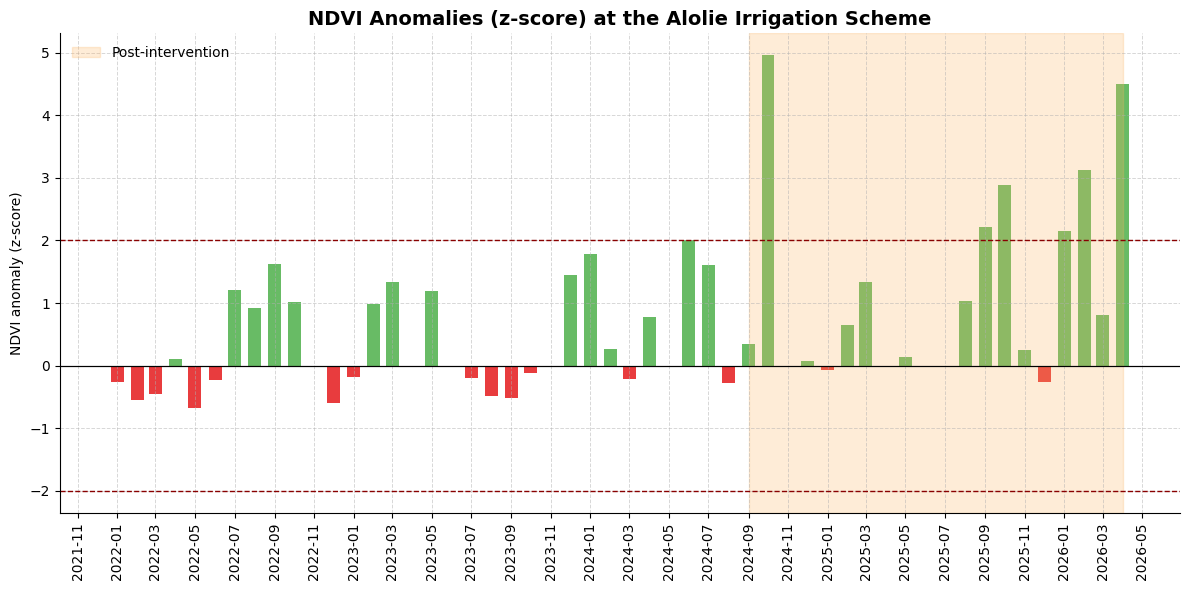

In [80]:
### ---------- ###

# ── Config — swap this out per project, nothing else changes
cfg = AnalysisConfig(
    study_start="2022-01-01",
    study_end="2026-04-30",
    baseline_start="2018-01-01",
    baseline_end="2023-12-31",
    intervention_date="2024-09-01",
)

# ── Geometries
aoi     = fc_from_geojson("../geojson/alenolie_irrigation_scheme.geojson")
control = fc_from_geojson("../geojson/control_field.geojson")
buffer  = fc_from_geojson("../geojson/buffer.geojson")

# Define the full Hanaano region box
hanaano_box = ee.Geometry.Polygon([
    [41.91,4.319],
    [41.96,4.319],
    [41.96,4.352],
    [41.91,4.352]
])

# # ── Run
# baseline      = compute_monthly_baseline(aoi, config=cfg, zone_label="aoi")
# result_seas   = seasonal_ndvi(aoi, config=cfg, zone_label="aoi")
# anomaly_seas  = compute_anomaly_images(
#     result_seas["collection"],
#     baseline["mean_images"],
#     baseline["std_images"],
#     temporal_resolution="seasonal",
#     config=cfg,
# )

# # ── Export — local
# export_ndvi_to_tiff(
#     anomaly_seas, "2023-dry1", hanaano_box,
#     output_dir="../outputs/tiff",
#     config=cfg,
#     label_prefix="Hanaano",
#     temporal_resolution="seasonal",
#     bands=["NDVI", "anomaly_abs"],
# )

# Data analysis and plotting
def data_analysis(
    geometry: GEEGeometry,
    config: AnalysisConfig = None,
    zone_label: str = "zone",
    temporal_resolution: Literal['monthly', 'seasonal'] = "monthly"
):
    
    baseline = compute_monthly_baseline(
        geometry=geometry,
        config=config,
        zone_label=zone_label
    )
    monthly = monthly_ndvi(
        geometry=geometry,
        config=config,
        zone_label=zone_label
    )
    df = compute_anomalies(
        study_df=monthly["dataframe"],
        baseline_df=baseline["dataframe"],
        config=config,
        temporal_resolution=temporal_resolution
    )
    return df

df = data_analysis(geometry=aoi, config=cfg, zone_label="Alolie Irrigation Scheme", temporal_resolution="monthly")
fig = barplot_ndvi_zscore(df=df, intervention_date=cfg.intervention_date, title=f"NDVI Anomalies (z-score) at the {df.zone.unique().item()}")
fig.show()

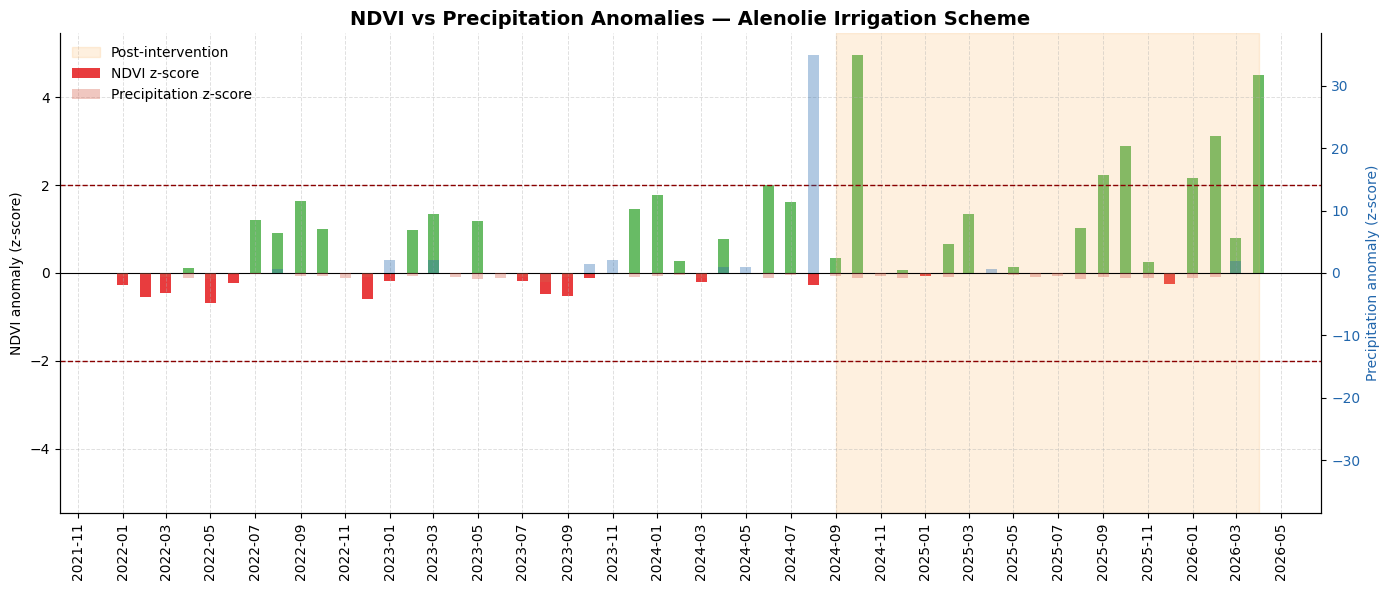

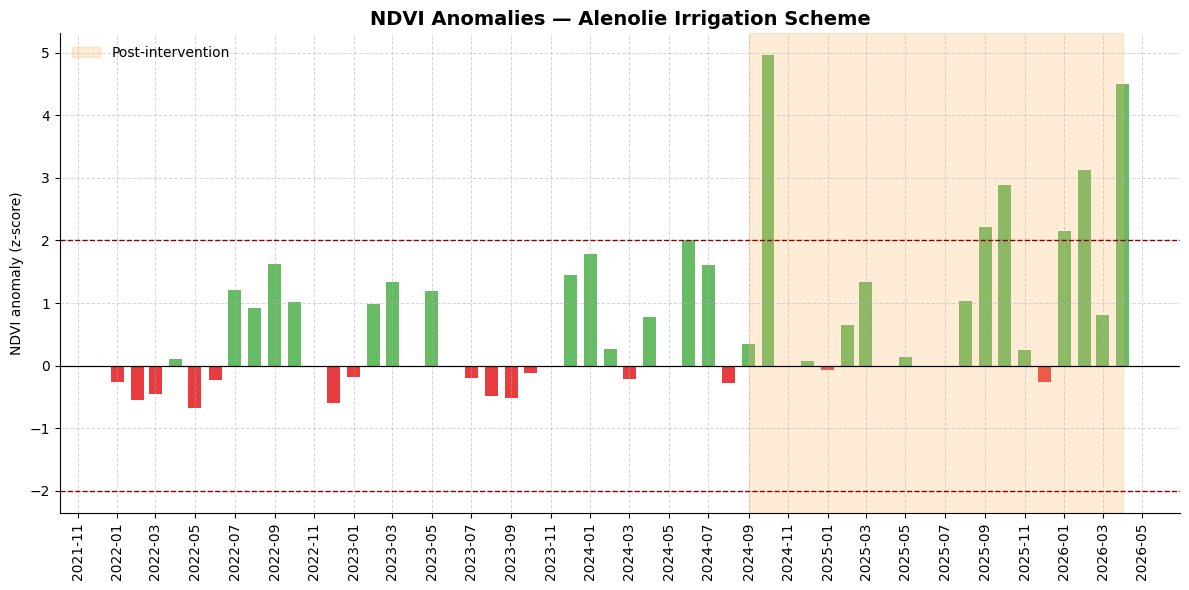

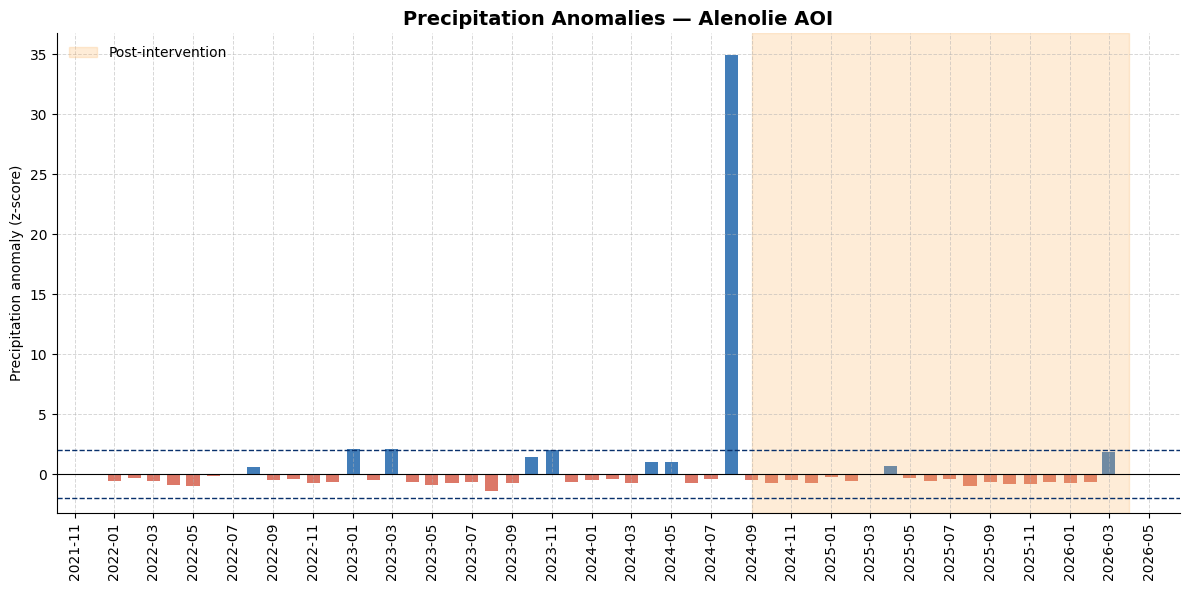

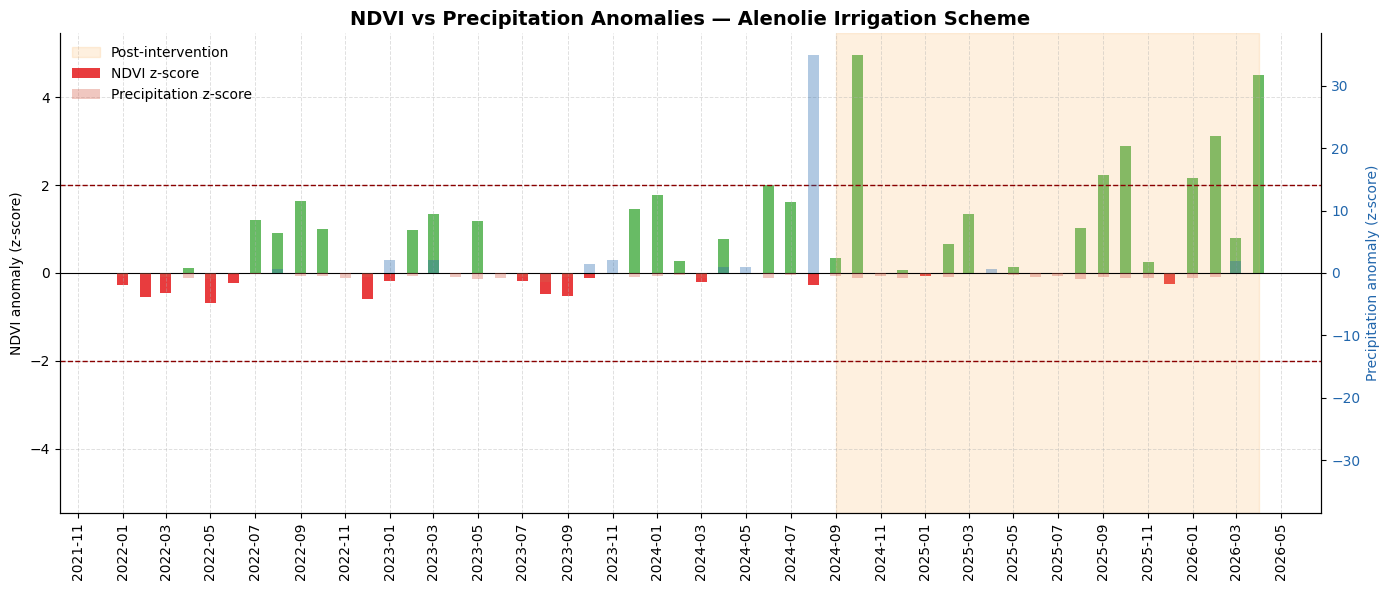

In [ ]:
# ── NDVI time series + baseline
ndvi_result = monthly_ndvi(aoi, cfg, "aoi")
ndvi_baseline = compute_monthly_baseline(aoi, cfg, "aoi")
ndvi_df = compute_anomalies(
        study_df=ndvi_result["dataframe"],
        baseline_df=ndvi_baseline["dataframe"],
        config=cfg,
        temporal_resolution="monthly"
    )

# ── CHIRPS time series + baseline
chirps_result  = build_chirps_monthly(hanaano_box, cfg.study_start, cfg.study_end)
chirps_baseline = compute_chirps_baseline(hanaano_box, cfg.baseline_start, cfg.baseline_end)
precip_df      = compute_precip_anomalies(chirps_result["dataframe"], chirps_baseline)

# ── Individual plots
barplot_ndvi_zscore(ndvi_df, intervention_date=cfg.intervention_date,
                    title="NDVI Anomalies — Alenolie Irrigation Scheme")

barplot_precip_zscore(precip_df, intervention_date=cfg.intervention_date,
                      title="Precipitation Anomalies — Alenolie AOI")

# ── Combined — the key diagnostic
barplot_ndvi_precip_combined(
    ndvi_df=ndvi_df,
    precip_df=precip_df,
    intervention_date=cfg.intervention_date,
    title="NDVI vs Precipitation Anomalies — Alenolie Irrigation Scheme",
)